## `distributions.ipynb`

This notebook plots different distribution and performance indices for HSC and DESI.

In [ ]:
## Imports
import numpy as np
import glob
import matplotlib.pyplot as plt
import os
import fitsio as fio

from pathlib import Path
from astropy import units as u
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy.io import fits
from astropy.table import Table

# Taking a look at the crossmatch files
USER_ROOT = Path("/global/cfs/cdirs/desicollab/users/jchdj")
USER_DATA = USER_ROOT / "desi-y3-hsc" / "data" / "xmatch"
desi_f = USER_DATA / "desi_xm_hsc_sep0_8.fits"
hsc_f = USER_DATA / "hsc_xm_desi_sep0_8.fits"

In [2]:
desi_xm = fio.FITS(desi_f)
hsc_xm = fio.FITS(hsc_f)

hsc = fio.FITS(
    "/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits"
)

Let's check the distributions and statistical properties of magnitude and redshift

Text(0.5, 1.0, 'HSC aperture mag distribution')

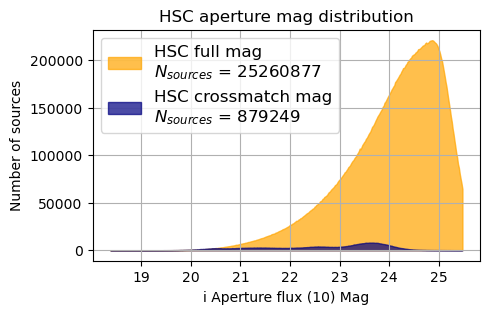

In [ ]:
plt.figure(figsize=(5, 3))
apmag = hsc_xm[1]["aperture_mag"].read()
maghsc_full = hsc[1]["aperture_mag"].read()
count_hsc, bins_hsc = np.histogram(apmag, bins=np.linspace(min(apmag), max(apmag), 400))

count_hsc_full, bins_hsc_full = np.histogram(
    maghsc_full, bins=np.linspace(min(apmag), max(apmag), 400)
)
plt.fill_between(
    bins_hsc_full[:-1],
    count_hsc_full,
    alpha=0.7,
    color="orange",
    label=f"HSC full mag\n" + r"$N_{sources}$" + f" = {len(maghsc_full)}",
)
plt.fill_between(
    bins_hsc[:-1],
    count_hsc,
    alpha=0.7,
    color="navy",
    label=f"HSC crossmatch mag\n" + r"$N_{sources}$" + f" = {len(apmag)}",
)
plt.grid()
plt.xlabel("i Aperture flux (10) Mag")
plt.ylabel("Number of sources")
plt.legend(loc="upper left", fontsize=12)
plt.title("HSC aperture mag distribution")

Text(0.5, 1.0, 'HSC / DESI z distribution')

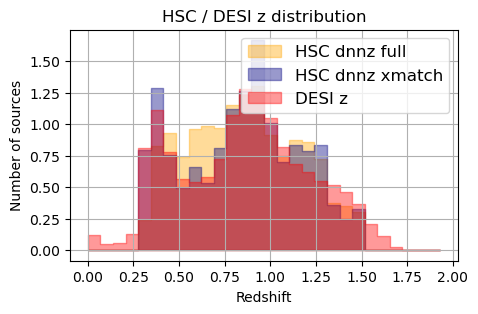

In [ ]:
plt.figure(figsize=(5, 3))

z_hsc = hsc_xm[1]["dnnz_photoz_best"].read()
zhsc_full = hsc[1]["dnnz_photoz_best"].read()

zbins = np.linspace(0, 2, 30)
count_hsc, bins_hsc = np.histogram(z_hsc, bins=zbins, density=True)
count_hsc_full, bins_hsc_full = np.histogram(zhsc_full, bins=zbins, density=True)
plt.fill_between(
    bins_hsc_full[:-1],
    count_hsc_full,
    alpha=0.4,
    color="orange",
    label=f"HSC dnnz full",
    step="post",
)
plt.fill_between(
    bins_hsc[:-1],
    count_hsc,
    alpha=0.4,
    color="navy",
    label=f"HSC dnnz xmatch",
    step="post",
)

z_desi = desi_xm[1]["Z"].read()
count_desi, bins_desi = np.histogram(z_desi, bins=zbins, density=True)
plt.fill_between(
    bins_desi[:-1], count_desi, alpha=0.4, color="red", label=f"DESI z", step="post"
)

plt.grid()
plt.xlabel("Redshift")
plt.ylabel("Number of sources")
plt.legend(loc="upper right", fontsize=12)
plt.title("HSC / DESI z distribution")

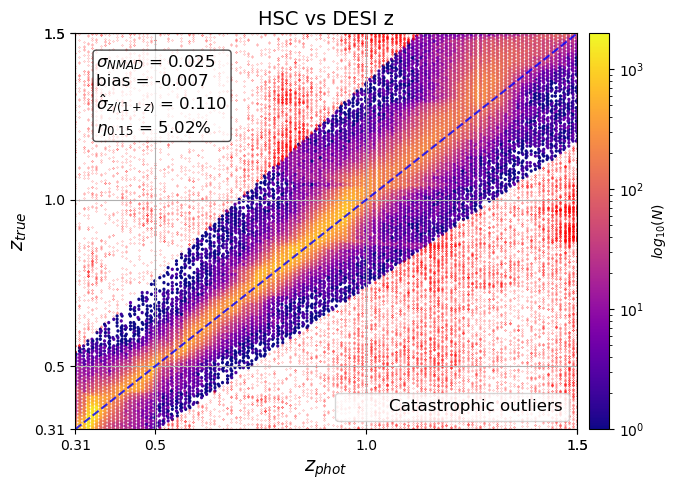

In [ ]:
# HSC / DESI z comparison
z_phot = hsc_xm[1]["dnnz_photoz_best"].read()
z_true = desi_xm[1]["Z"].read()
cmap = plt.get_cmap("plasma")

plt.figure(figsize=(7, 5))

dz = z_phot - z_true
nmad = 1.4826 * np.median(np.abs(dz - np.median(dz)) / (1 + z_true))
bias = np.median(dz / (1 + z_true))
nr = np.abs(dz) / (1 + z_true)
std = np.std(nr)
bool_out = nr > 0.15  # 3*std
frac = np.sum(bool_out) / len(bool_out)

ztext = (
    r"$\sigma_{NMAD}$"
    + f" = {nmad:.3f}\nbias = {bias:.3f}\n"
    + r"$\hat{\sigma}_{z/(1+z)}$"
    + f" = {std:.3f}\n"
    + r"$\eta_{0.15}$"
    + f" = {frac*100:.2f}%"
)

plt.hexbin(
    z_phot[~bool_out],
    z_true[~bool_out],
    gridsize=300,
    cmap=cmap,
    bins="log",
    mincnt=1,
    label="",
)
plt.colorbar(label=r"$log_{10}(N)$", pad=0.02)
plt.scatter(
    z_phot[bool_out],
    z_true[bool_out],
    color="red",
    s=0.03,
    alpha=0.8,
    label="Catastrophic outliers",
)

plt.xlabel(r"$z_{phot}$", fontsize=14)
plt.ylabel(r"$z_{true}$", fontsize=14)
bds = [min(z_phot), max(z_phot)]
plt.ylim(bds[0], bds[1])
plt.xlim(bds[0], bds[1])
plt.plot(bds, bds, "b--", alpha=0.8)
plt.yticks([bds[0], 0.5, 1, 1.5, bds[1]], labels=[bds[0], 0.5, 1.0, 1.5, bds[1]])
plt.xticks([bds[0], 0.5, 1, 1.5, bds[1]], labels=[bds[0], 0.5, 1.0, 1.5, bds[1]])


plt.text(
    bds[0] + 0.05,
    bds[1] - 0.3,
    ztext,
    fontsize=12,
    bbox=dict(
        facecolor="white", alpha=0.7, edgecolor="black", boxstyle="round,pad=0.2"
    ),
)

plt.grid()
plt.title("HSC vs DESI z", fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.tight_layout()

(18.371692657470703, 25.497798919677734)

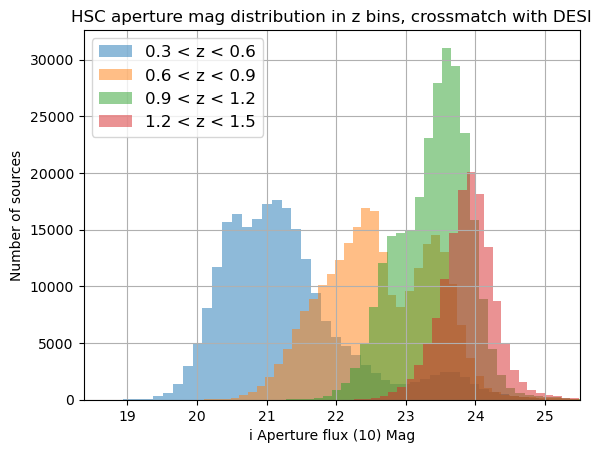

In [36]:
HSC_bins_z = [0.3, 0.6, 0.9, 1.2, 1.5]
maghsc = hsc[1]["aperture_mag"].read()
zhsc = hsc[1]["dnnz_photoz_best"].read()

for i in range(len(HSC_bins_z) - 1):
    crit = (HSC_bins_z[i] < zhsc) & (zhsc <= HSC_bins_z[i + 1])
    maghsc_bin = maghsc[crit]
    plt.hist(
        maghsc_bin,
        bins=50,
        alpha=0.5,
        label=f"{HSC_bins_z[i]} < z < {HSC_bins_z[i+1]}",
        histtype="stepfilled",
    )
plt.xlabel("i Aperture flux (10) Mag")
plt.ylabel("Number of sources")
plt.legend(loc="upper left", fontsize=12)
plt.title("HSC aperture mag distribution in z bins, crossmatch with DESI")
plt.grid()
plt.xlim(min(maghsc), max(maghsc))

In [13]:
USER_ROOT = Path("/global/cfs/cdirs/desicollab/users/jchdj")
DATA_ROOT = USER_ROOT / "desi-y3-hsc" / "data"
DESI_ROOT = DATA_ROOT / "desi" / "cat"
HSC_ROOT = DATA_ROOT / "hsc" / "cat"
XMATCH_ROOT = DATA_ROOT / "xmatch"

# Find the desi file
desi_file = Path(DESI_ROOT, "desiy3_cut_cat.fits")
print(f"DESI sampled catalog : {desi_file}")

# Find HSC data
hsc_file = Path(HSC_ROOT, "hscy3_cat.fits")
print(f"HSC catalog : {hsc_file}")

DESI sampled catalog : /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/desi/cat/desiy3_cut_cat.fits
HSC catalog : /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits


(18.371692657470703, 25.499998092651367)

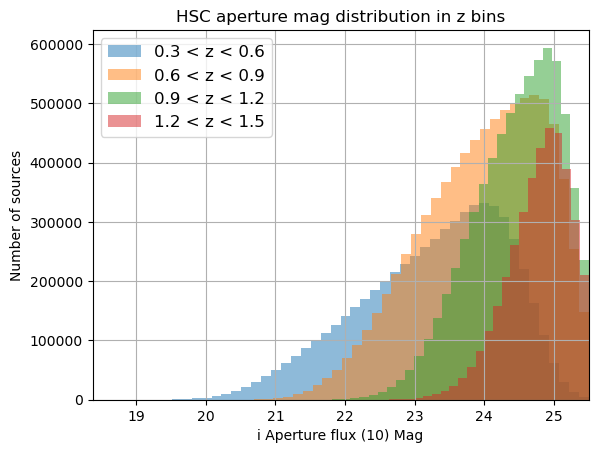

In [35]:
HSC_bins_z = [0.3, 0.6, 0.9, 1.2, 1.5]
with fio.FITS(hsc_file) as hsc_full:
    data = hsc_full[1].read(columns=["aperture_mag", "dnnz_photoz_best"])

maghsc_full = data["aperture_mag"]
zhsc_full = data["dnnz_photoz_best"]


for i in range(len(HSC_bins_z) - 1):
    crit = (HSC_bins_z[i] < zhsc_full) & (zhsc_full <= HSC_bins_z[i + 1])
    maghsc_full_bin = maghsc_full[crit]
    plt.hist(
        maghsc_full_bin,
        bins=50,
        alpha=0.5,
        label=f"{HSC_bins_z[i]} < z < {HSC_bins_z[i+1]}",
        histtype="stepfilled",
    )
plt.xlabel("i Aperture flux (10) Mag")
plt.ylabel("Number of sources")
plt.legend(loc="upper left", fontsize=12)
plt.title("HSC aperture mag distribution in z bins")
plt.grid()
plt.xlim(min(maghsc_full), max(maghsc_full))

In [23]:
from desitarget.targetmask import desi_mask

desi_tgt = desi[1]["DESI_TARGET"].read()

is_bgs = desi_tgt & desi_mask.BGS_ANY != 0  # - instead of 2**60
is_lrg = desi_tgt & desi_mask.LRG != 0
is_elg = desi_tgt & desi_mask.ELG != 0
is_qso = desi_tgt & desi_mask.QSO != 0
is_mws = desi_tgt & desi_mask.MWS_ANY != 0
is_scnd = desi_tgt & desi_mask.SCND_ANY != 0
masks = {
    "BGS": is_bgs,
    "LRG": is_lrg,
    "ELG": is_elg,
    "QSO": is_qso,
    #'MWS': is_mws,
    #'SCND': is_scnd
}

BGS: 115725
LRG: 200601
ELG: 341808
QSO: 7317


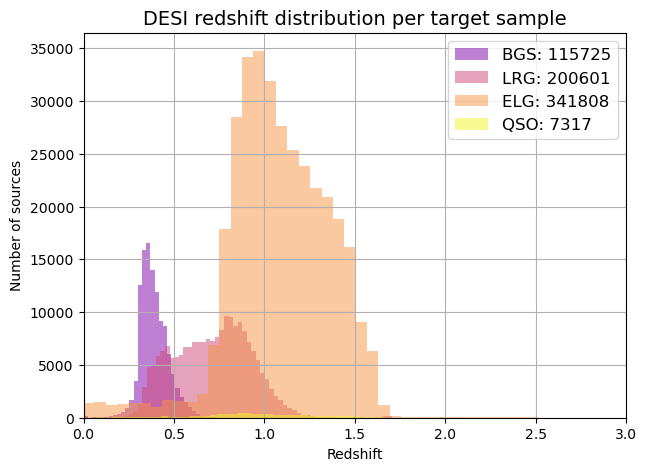

In [31]:
cmap = plt.get_cmap("plasma")
z_samp = desi[1]["Z"].read()
plt.figure(figsize=(7, 5))

for i, (key, mask) in enumerate(masks.items()):
    print(f"{key}: {np.sum(mask)}")
    plt.hist(
        z_samp[mask],
        bins=100,
        alpha=0.5,
        label=f"{key}: {np.sum(mask)}",
        histtype="stepfilled",
        color=cmap((i + 1) / 4),
    )

plt.xlabel("Redshift")
plt.ylabel("Number of sources")
plt.legend(loc="upper right", fontsize=12)
plt.title("DESI redshift distribution per target sample", fontsize=14)
plt.xlim(0, 3)
# plt.yscale('log')
plt.grid()

In [34]:
print(f"Sources with SPECZ (crossmatch) : {desi[1].get_nrows()}")
print(f"Sources with HSC data (not crossmatched) : {len(maghsc_full)}")
print(
    f"Percentage of sources with HSC data (not crossmatched) : {desi[1].get_nrows()/len(maghsc_full)*100:.2f}%"
)

Sources with SPECZ (crossmatch) : 879249
Sources with HSC data (not crossmatched) : 25260877
Percentage of sources with HSC data (not crossmatched) : 3.48%


879249
879249


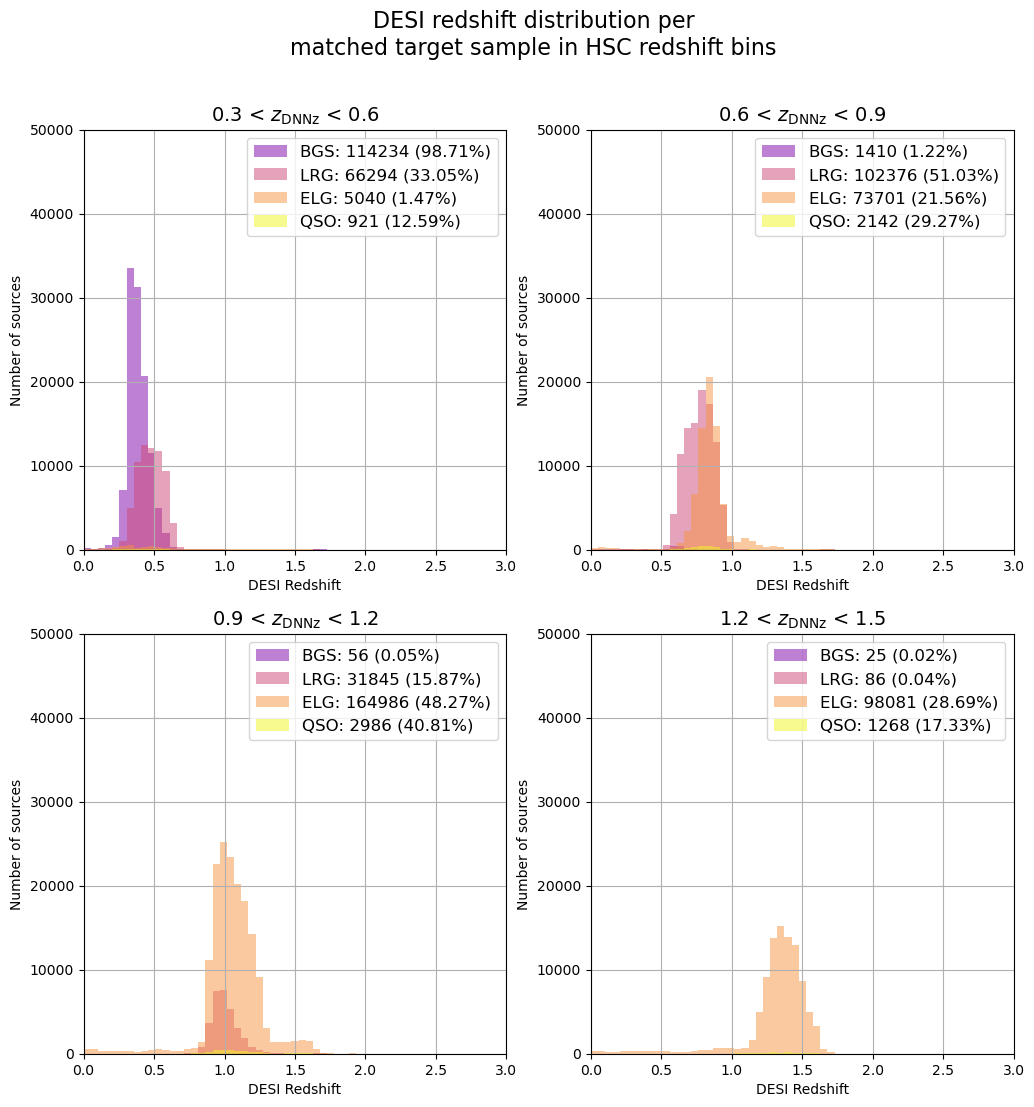

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
zb = np.linspace(0, 3, 60)
# crossplot of DESI samples per HSC_redshift bin
axs = axs.flatten()
zhsc = hsc[1]["dnnz_photoz_best"].read()
z_desi = desi_xm[1]["Z"].read()
print(len(z_desi))
print(len(zhsc))

for i in range(len(HSC_bins_z) - 1):
    crit = (HSC_bins_z[i] < zhsc) & (zhsc <= HSC_bins_z[i + 1])
    for j, (key, mask) in enumerate(masks.items()):
        axs[i].hist(
            z_desi[mask & crit],
            bins=zb,
            alpha=0.5,
            label=f"{key}: {np.sum(mask & crit)} ({np.sum(mask & crit)/np.sum(mask)*100:.2f}%)",
            histtype="stepfilled",
            color=cmap((j + 1) / 4),
        )
    axs[i].set_xlabel("DESI Redshift")
    axs[i].set_ylabel("Number of sources")
    axs[i].legend(loc="upper right", fontsize=12)
    axs[i].set_title(
        f"{HSC_bins_z[i]} < " + r"$z_{\mathrm{DNNz}}$" f" < {HSC_bins_z[i+1]}",
        fontsize=14,
    )
    axs[i].set_xlim(0, 3)
    # axs[i].set_yscale('log')
    axs[i].set_ylim(0, 50000)
    axs[i].grid()
fig.suptitle(
    "DESI redshift distribution per\nmatched target sample in HSC redshift bins",
    fontsize=16,
)
plt.subplots_adjust(hspace=0.2, wspace=0.2)

879249
879249


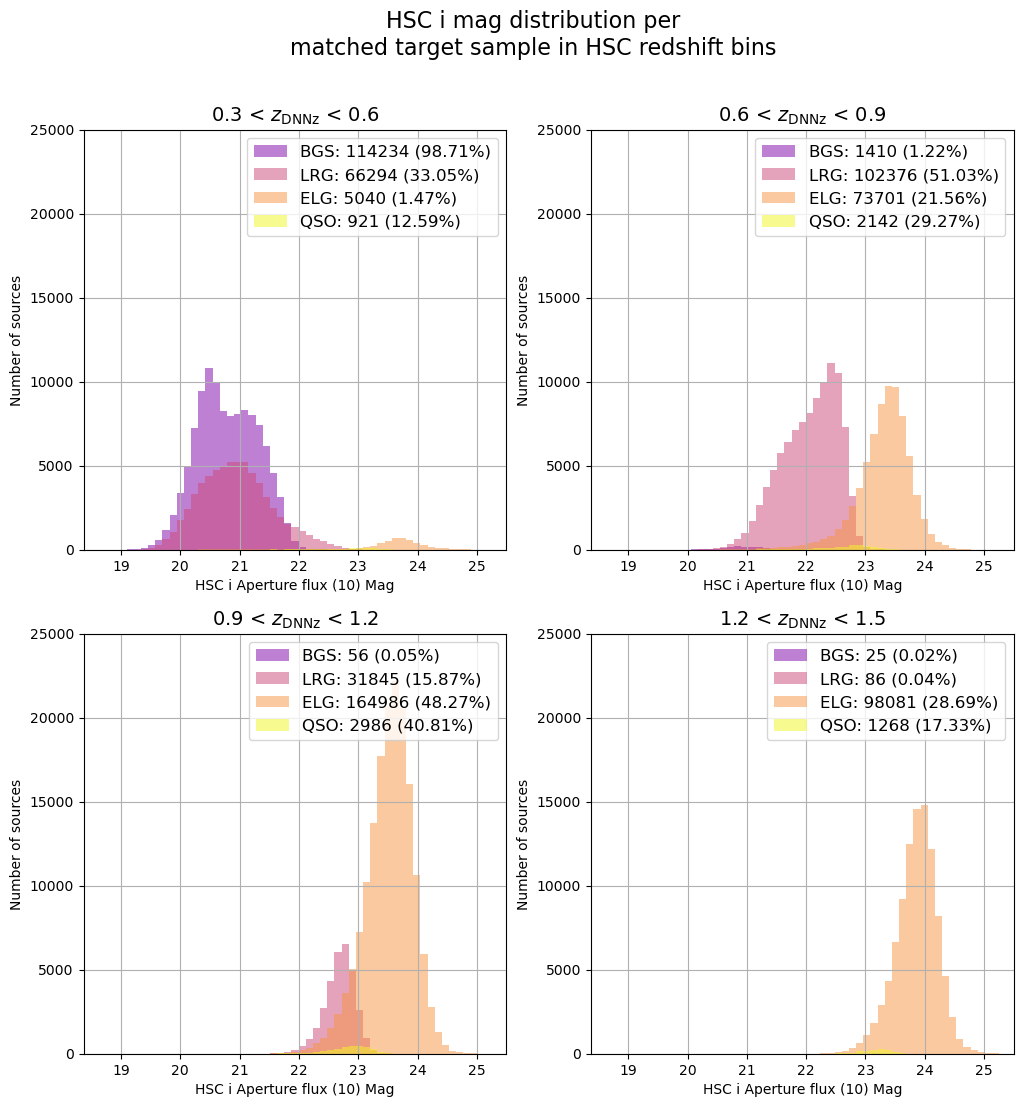

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
zb = np.linspace(min(maghsc), max(maghsc), 60)
# crossplot of DESI samples per HSC_redshift bin
axs = axs.flatten()
zhsc = hsc[1]["dnnz_photoz_best"].read()
z_desi = desi_xm[1]["Z"].read()
print(len(z_desi))
print(len(zhsc))

for i in range(len(HSC_bins_z) - 1):
    crit = (HSC_bins_z[i] < zhsc) & (zhsc <= HSC_bins_z[i + 1])
    for j, (key, mask) in enumerate(masks.items()):
        axs[i].hist(
            maghsc[mask & crit],
            bins=zb,
            alpha=0.5,
            label=f"{key}: {np.sum(mask & crit)} ({np.sum(mask & crit)/np.sum(mask)*100:.2f}%)",
            histtype="stepfilled",
            color=cmap((j + 1) / 4),
        )
    axs[i].set_xlabel("HSC i Aperture flux (10) Mag")
    axs[i].set_xlim(min(maghsc), max(maghsc))
    axs[i].set_ylabel("Number of sources")
    axs[i].legend(loc="upper right", fontsize=12)
    axs[i].set_title(
        f"{HSC_bins_z[i]} < " + r"$z_{\mathrm{DNNz}}$" f" < {HSC_bins_z[i+1]}",
        fontsize=14,
    )
    # axs[i].set_yscale('log')
    axs[i].set_ylim(0, 25000)
    axs[i].grid()
fig.suptitle(
    "HSC i mag distribution per\nmatched target sample in HSC redshift bins",
    fontsize=16,
)
plt.subplots_adjust(hspace=0.2, wspace=0.2)